[*********************100%***********************]  5 of 5 completed


=== 日次対数リターン ===
Ticker          AAPL      AMZN       JNJ       JPM      MSFT
Date                                                        
2000-01-04 -0.088078 -0.086884 -0.037297 -0.022185 -0.034365
2000-01-05  0.014527 -0.161039  0.010501 -0.006192  0.010489
2000-01-06 -0.090514 -0.061914  0.030855  0.014098 -0.034072
2000-01-07  0.046281  0.059222  0.041659  0.018206  0.012983
2000-01-10 -0.017744 -0.005405 -0.025584 -0.017331  0.007265
...              ...       ...       ...       ...       ...
2025-12-23  0.005117  0.016111 -0.007456  0.008752  0.003972
2025-12-24  0.005310  0.001033  0.009672  0.009892  0.002400
2025-12-26 -0.001499  0.000602 -0.000722 -0.003835 -0.000635
2025-12-29  0.001316 -0.001937 -0.000337 -0.012768 -0.001252
2025-12-30 -0.002487  0.001980 -0.003137 -0.001020  0.000780

[6537 rows x 5 columns]
=== 年率リターン ===
Ticker
AAPL    0.2230
AMZN    0.1523
JNJ     0.0840
JPM     0.1019
MSFT    0.1009
dtype: float64

=== 年率ボラティリティ ===
Ticker
AAPL    0.3981
AMZN    0.48

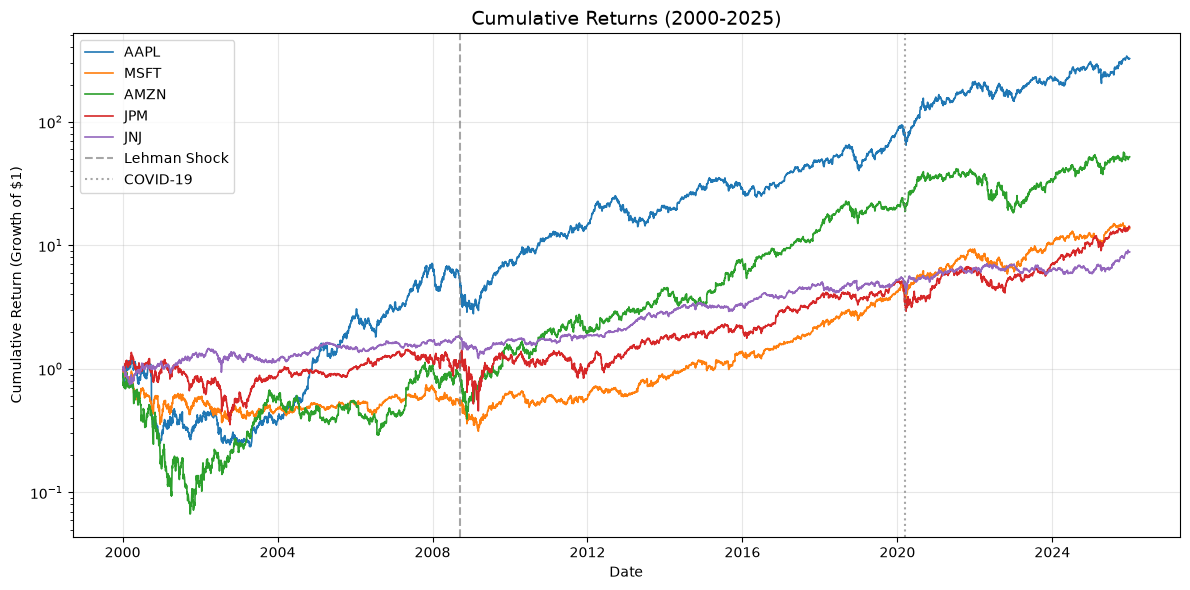

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize

# データ取得
tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']
data = yf.download(tickers, start='2000-01-01', end='2025-12-31')['Close']

# 日次対数リターン
log_returns = np.log(data / data.shift(1)).dropna()

print("=== 日次対数リターン ===")
print(log_returns)

# 日次単純リターン
simple_returns = data.pct_change().dropna()

# 年率リターンと年率ボラティリティ
annual_return = log_returns.mean() * 252
annual_vol = log_returns.std() * np.sqrt(252)

print("=== 年率リターン ===")
print(annual_return.round(4))
print("\n=== 年率ボラティリティ ===")
print(annual_vol.round(4))

# 累積リターン（対数リターンの累積和 → 指数変換）
cumulative = (1 + simple_returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
for ticker in tickers:
    ax.plot(cumulative.index, cumulative[ticker], label=ticker, linewidth=1.2)

# リーマンショック・コロナショックの時期に縦線
ax.axvline(pd.Timestamp('2008-09-15'), color='gray', linestyle='--', alpha=0.7, label='Lehman Shock')
ax.axvline(pd.Timestamp('2020-03-11'), color='gray', linestyle=':', alpha=0.7, label='COVID-19')

ax.set_title('Cumulative Returns (2000-2025)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (Growth of $1)')
ax.legend(loc='upper left')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()